In [ ]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns

# Natural Language Processing Libraries
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# PyTorch Libraries
import torch
from torch.utils.data import Dataset, DataLoader

# Evaluation Metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, f1_score, recall_score, precision_score
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight

In [12]:
# Load the CIC-IDS-2017 datasets
datasets = {
    'Benign-Monday': 'Monday-WorkingHours.pcap_ISCX.csv',
    'Botnet-Friday': 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Bruteforce-Tuesday': 'Tuesday-WorkingHours.pcap_ISCX.csv',
    'DDoS-Friday': 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'DoS-Wednesday': 'Wednesday-workingHours.pcap_ISCX.csv',
    'Infiltration-Thursday': 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Portscan-Friday': 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'WebAttacks-Thursday': 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
}

# Read the datasets into DataFrames
df_data = {key: pd.read_csv(path) for key, path in datasets.items()}

for df in df_data.values():
    df.columns = df.columns.str.strip()

In [11]:
# Display the first 5 rows of each DataFrame
for name, df in df_data.items():
    print(f"Head of {name}:")
    # print(df.head(), "\n")

Head of Benign-Monday:
Head of Botnet-Friday:
Head of Bruteforce-Tuesday:
Head of DDoS-Friday:
Head of DoS-Wednesday:
Head of Infiltration-Thursday:
Head of Portscan-Friday:
Head of WebAttacks-Thursday:


In [13]:
# Concatenate all DataFrames into one
df_all = pd.concat(df_data.values(), ignore_index=True)

# Display the first 5 rows of the concatenated DataFrame
# print(df_all.head())

In [14]:
print(df_all.head())

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             49188              4                  2                       0   
1             49188              1                  2                       0   
2             49188              1                  2                       0   
3             49188              1                  2                       0   
4             49486              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                           12                            0   
2                           12                            0   
3                           12                            0   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [15]:
# Find and handle null values

# Get the count of null values in each column
null_counts = df_all.isnull().sum()

# Print the total number of null entries in the dataset
print(f"Total null entries found: {null_counts.sum()}\n")

# Drop rows with any null values
df_all.dropna(inplace=True)  

# Find and handle duplicates

# Get the count of duplicate rows
duplicate_count = df_all.duplicated().sum()

# # Print the number of duplicate entries found
print(f"Total duplicate entries found: {duplicate_count}\n")

# Remove duplicate rows from the dataset
df_all.drop_duplicates(inplace=True) 

# Inform that duplicates have been removed
print("All duplicate entries have been removed.\n")

# Reset the index after dropping rows
df_all.reset_index(drop=True, inplace=True)

# Inspect categorical columns
categorical_columns = df_all.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_columns}\n")

# Display the first 5 rows of the cleaned dataset
df_all.head(20)

Total null entries found: 1358

Total duplicate entries found: 307376

All duplicate entries have been removed.

Categorical columns: ['Label']



C:\Users\warre\AppData\Local\Temp\ipykernel_18652\3139046159.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_all.select_dtypes(include=['object']).columns.tolist()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49486,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,609,7,4,484,414,233,0,69.142857,111.967895,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,88,879,9,4,656,3064,313,0,72.888889,136.153814,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,88,1160,9,6,3134,3048,1552,0,348.222222,682.482560,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,88,524,7,4,2812,2820,1397,0,401.714286,679.914876,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,1034,6,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,88,1119,9,6,3160,3060,1565,0,351.111111,688.214982,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [16]:
print ('Shape of Dataframe:', df_all.shape, '\n')
print('Inspection of tarfer Feature - y:\n', df_all['Label'].value_counts())

Shape of Dataframe: (2522009, 79) 

Inspection of tarfer Feature - y:
 Label
BENIGN                        2096134
DoS Hulk                       172846
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [18]:
X = df_all.drop(columns=['Label'])
Y = (df_all['Label'] != 'BENIGN').astype(int)  # Convert to binary labels: 0 for BENIGN, 1 for ATTACK

Class Distribution:
🟦 Benign (0): 2,096,134 samples (83.11%)
🟥 Malicious (1): 425,875 samples (16.89%)



C:\Users\warre\AppData\Local\Temp\ipykernel_18652\2606372007.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=["blue", "red"])


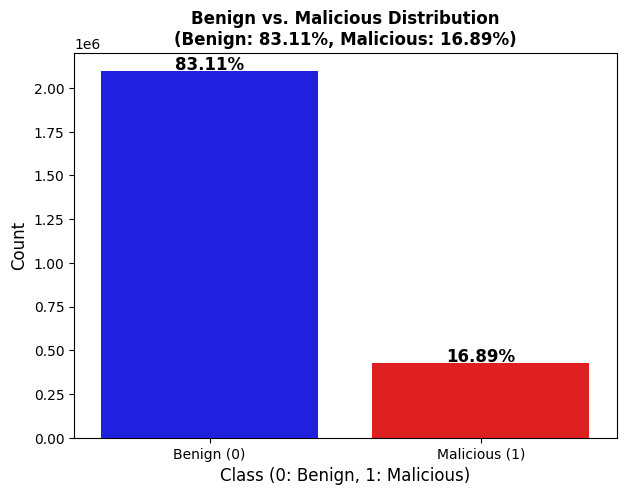

In [20]:
# Count occurrences of each class
class_counts = Y.value_counts()
total_samples = len(Y)

# Calculate percentage of each class
benign_ratio = (class_counts[0] / total_samples) * 100
malicious_ratio = (class_counts[1] / total_samples) * 100

# Print ratios in a clean format
print(f"Class Distribution:\n"
      f"🟦 Benign (0): {class_counts[0]:,} samples ({benign_ratio:.2f}%)\n"
      f"🟥 Malicious (1): {class_counts[1]:,} samples ({malicious_ratio:.2f}%)\n")

# Plot the distribution
plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=["blue", "red"])

# Add labels and title
plt.xlabel("Class (0: Benign, 1: Malicious)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title(f"Benign vs. Malicious Distribution\n(Benign: {benign_ratio:.2f}%, Malicious: {malicious_ratio:.2f}%)",
          fontsize=12, fontweight="bold")

# Show percentage on top of bars
for i, val in enumerate(class_counts.values):
    plt.text(i, val + 10000, f"{(val/total_samples)*100:.2f}%", 
             ha='center', fontsize=12, fontweight='bold', color='black')

plt.xticks([0, 1], ["Benign (0)", "Malicious (1)"])
plt.show()

In [21]:
df_all.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49486,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,609,7,4,484,414,233,0,69.142857,111.967895,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [23]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and temporary set (validation + test)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Further split the temporary set into validation and test sets
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

# Check the size of each set
print(f"Training Set: {X_train.shape[0]} samples")
print(f"Validation Set: {X_val.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")


Training Set: 2017607 samples
Validation Set: 252201 samples
Test Set: 252201 samples


In [28]:
# 1. Replace inf with NaN and drop them from your feature sets
def clean_inf_nan(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

# Apply to your data (ensure labels Y stay aligned with rows in X)
# Note: It's safer to do this on the original 'df' before splitting into X and Y
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


In [31]:
# A. Convert all feature columns to numeric, forcing errors to NaN
# This catches strings like "Inf" or empty spaces that aren't np.inf objects
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# B. Replace actual infinity and drop ANY remaining NaN
def force_clean(X, Y):
    X = X.replace([np.inf, -np.inf], np.nan)
    # Get indices of rows that are completely finite
    keep_indices = X.dropna().index
    return X.loc[keep_indices], Y.loc[keep_indices]

X_train, Y_train = force_clean(X_train, Y_train)
X_val, Y_val = force_clean(X_val, Y_val)
X_test, Y_test = force_clean(X_test, Y_test)

# C. FINAL CHECK: This MUST print 0 before you scale
print(f"Total NaNs/Infs in Train: {X_train.isin([np.inf, -np.inf]).sum().sum() + X_train.isna().sum().sum()}")

Total NaNs/Infs in Train: 0


In [32]:
def robust_scale_data(X_train, X_val, X_test):
    """
    Perform Robust Scaling on the features of the training, validation, and test datasets.

    Robust Scaling scales the data using the median and interquartile range (IQR), 
    making it less sensitive to outliers compared to other scaling methods.

    Parameters:
    - X_train (pd.DataFrame): Training dataset with original features.
    - X_val   (pd.DataFrame): Validation dataset with original features.
    - X_test  (pd.DataFrame): Test dataset with original features.

    Returns:
    - Tuple of pd.DataFrame: Scaled training, validation, and test datasets.
    """
    # Initialize the RobustScaler
    scaler = RobustScaler()

    # Fit the scaler on the training data and transform all datasets
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

    return X_train_scaled, X_val_scaled, X_test_scaled

# Apply Robust Scaling to the datasets
X_train_scaled, X_val_scaled, X_test_scaled = robust_scale_data(X_train, X_val, X_test)

# Combine scaled datasets and labels into a list for easy access
scaled_data = [X_train_scaled, X_val_scaled, X_test_scaled, Y_train, Y_val, Y_test]

In [33]:
# Selecting Data Configuration

# Option 1: Use original data (unscaled)
# [X_train, X_val, X_test, y_train, y_val, y_test] = original_data

# Option 2: Use scaled data (preprocessed)
[X_train, X_val, X_test, y_train, y_val, y_test] = scaled_data

In [35]:
# Set random seed for reproducibility
seed = 42
np.random.seed(seed)

# Define XGBoost model parameters
xgb_params = {
    "objective": "binary:logistic",  # Binary classification objective
    "eval_metric": "logloss",  # Evaluation metric for model performance
    "max_depth": 6,  # Maximum depth of trees
    "learning_rate": 0.01,  # Learning rate (eta)
    "n_estimators": 1000,  # Number of boosting rounds
    "subsample": 0.8,  # Fraction of data used per tree
    "colsample_bytree": 0.8,  # Fraction of features used per tree
    "reg_alpha": 0.1,  # L1 regularization term
    "reg_lambda": 1.0,  # L2 regularization term
    "random_state": seed,  # Random seed
    "use_label_encoder": False  # Avoid warning for label encoding
}

# Initialize XGBoost classifier
xgb_clf = xgb.XGBClassifier(**xgb_params)

# Inspect model parameters
print(xgb_clf.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1000, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}


c:\Users\warre\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\callback.py:385: UserWarning: [20:59:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-logloss:0.68360	val-logloss:0.68360
[10]	train-logloss:0.59853	val-logloss:0.59849
[20]	train-logloss:0.52762	val-logloss:0.52755
[30]	train-logloss:0.46794	val-logloss:0.46786
[40]	train-logloss:0.41671	val-logloss:0.41660
[50]	train-logloss:0.37197	val-logloss:0.37184
[60]	train-logloss:0.33362	val-logloss:0.33349
[70]	train-logloss:0.29983	val-logloss:0.29968
[80]	train-logloss:0.27000	val-logloss:0.26985
[90]	train-logloss:0.24396	val-logloss:0.24380
[100]	train-logloss:0.22069	val-logloss:0.22052
[110]	train-logloss:0.19988	val-logloss:0.19970
[120]	train-logloss:0.18132	val-logloss:0.18113
[130]	train-logloss:0.16476	val-logloss:0.16456
[140]	train-logloss:0.14989	val-logloss:0.14971
[150]	train-logloss:0.13652	val-logloss:0.13635
[160]	train-logloss:0.12465	val-logloss:0.12449
[170]	train-logloss:0.11398	val-logloss:0.11381
[180]	train-logloss:0.10435	val-logloss:0.10420
[190]	train-logloss:0.09570	val-logloss:0.09555
[200]	train-logloss:0.08788	val-logloss:0.08774
[21

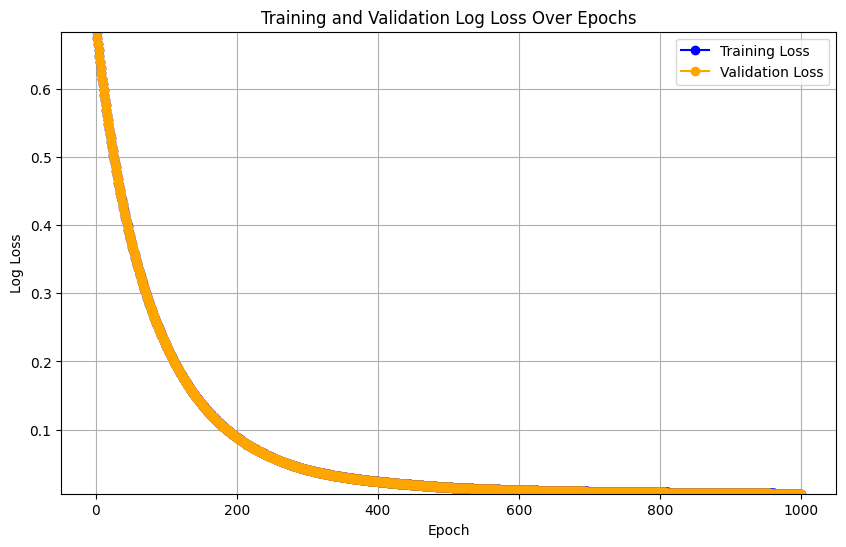

In [36]:
# Set random seed for reproducibility
seed = 42
np.random.seed(seed)

# Prepare data
# Assuming X_train, X_val, y_train, and y_val are preprocessed and ready for training
try:
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
except NameError:
    raise NameError("X_train, X_val, y_train, or y_val is not defined. Please ensure the data is loaded and preprocessed.")

# Compute class weights for handling imbalance
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
scale_pos_weight = class_weights[1] / class_weights[0]  # Adjust for imbalance

# Define XGBoost parameters
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "learning_rate": 0.01,
    "n_estimators": 1000,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": seed,
    "scale_pos_weight": scale_pos_weight,  # Handle class imbalance
}

# Initialize XGBoost model and capture evaluation results
evals_result = {}  # Dictionary to store evaluation results
try:
    xgb_clf = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dtrain, "train"), (dval, "val")],
        early_stopping_rounds=10,
        verbose_eval=10,
        evals_result=evals_result  # Capture evaluation results
    )
except Exception as e:
    raise RuntimeError(f"Error training XGBoost model: {e}")

# Make predictions on validation set
val_preds_prob = xgb_clf.predict(dval)
val_preds = (val_preds_prob > 0.5).astype(int)

# Compute validation metrics
val_accuracy = accuracy_score(y_val, val_preds)
val_precision = precision_score(y_val, val_preds)
val_recall = recall_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds)
val_auc = roc_auc_score(y_val, val_preds_prob)

print("\nValidation Metrics:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")
print(f"AUC-ROC: {val_auc:.4f}")

# Save the best model
xgb_clf.save_model("best_xgboost_model.json")

# Load the best model
best_xgb = xgb.Booster()
best_xgb.load_model("best_xgboost_model.json")

def plot_training_xgboost(evals_result):
    """
    Plots the training and validation loss over epochs for an XGBoost model.
    
    Parameters:
        evals_result (dict): Dictionary containing evaluation results.
    """
    # Extract training and validation logloss values
    train_logloss = evals_result['train']['logloss']
    val_logloss = evals_result['val']['logloss']

    # Create an array of epoch numbers
    epochs = range(1, len(train_logloss) + 1)

    # Create a line plot to visualize the loss over epochs
    plt.figure(figsize=(10, 6))

    # Use consistent styling for the plot
    plt.plot(epochs, train_logloss, label='Training Loss', marker='o', linestyle='-', color='blue')
    plt.plot(epochs, val_logloss, label='Validation Loss', marker='o', linestyle='-', color='orange')

    # Label the axes and add a title
    plt.xlabel('Epoch')
    plt.ylabel('Log Loss')
    plt.title('Training and Validation Log Loss Over Epochs')

    # Add a legend and grid
    plt.legend()
    plt.grid(True)

    # Automatically adjust the plot to the range of values
    plt.gca().autoscale(enable=True, axis='y', tight=True)

    # Display the plot
    plt.show()

# Create the plot
try:
    plot_training_xgboost(evals_result)
except NameError:
    raise NameError("evals_result is not defined. Ensure the XGBoost model is trained successfully.")

In [46]:
print("\nValidation Metrics:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")
print(f"AUC-ROC: {val_auc:.4f}")
print(f'Confusion Matrix:\n{confusion_matrix(y_val, val_preds)}')
print(f"Classification Report:\n{classification_report(y_val, val_preds)}")


Validation Metrics:
Accuracy: 0.9986
Precision: 0.9925
Recall: 0.9994
F1-Score: 0.9959
AUC-ROC: 0.9999
Confusion Matrix:
[[209190    323]
 [    27  42547]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209513
           1       0.99      1.00      1.00     42574

    accuracy                           1.00    252087
   macro avg       1.00      1.00      1.00    252087
weighted avg       1.00      1.00      1.00    252087



Top 25 Features:
Destination Port: 1.0000
Init_Win_bytes_forward: 0.8157
Init_Win_bytes_backward: 0.7824
Fwd IAT Min: 0.2795
Fwd Header Length: 0.2060
Bwd Packet Length Std: 0.1742
Flow IAT Min: 0.1635
min_seg_size_forward: 0.1218
Total Backward Packets: 0.1150
Total Length of Bwd Packets: 0.1082
Bwd Packet Length Mean: 0.0933
Bwd Packets/s: 0.0865
Packet Length Std: 0.0580
Fwd Packet Length Max: 0.0427
Average Packet Size: 0.0411
Total Length of Fwd Packets: 0.0376
Active Min: 0.0356
Flow Bytes/s: 0.0249
Flow Duration: 0.0223
Max Packet Length: 0.0159
Total Fwd Packets: 0.0091
PSH Flag Count: 0.0055
Bwd Header Length: 0.0049
Fwd Packet Length Std: 0.0036
Bwd Packet Length Max: 0.0000




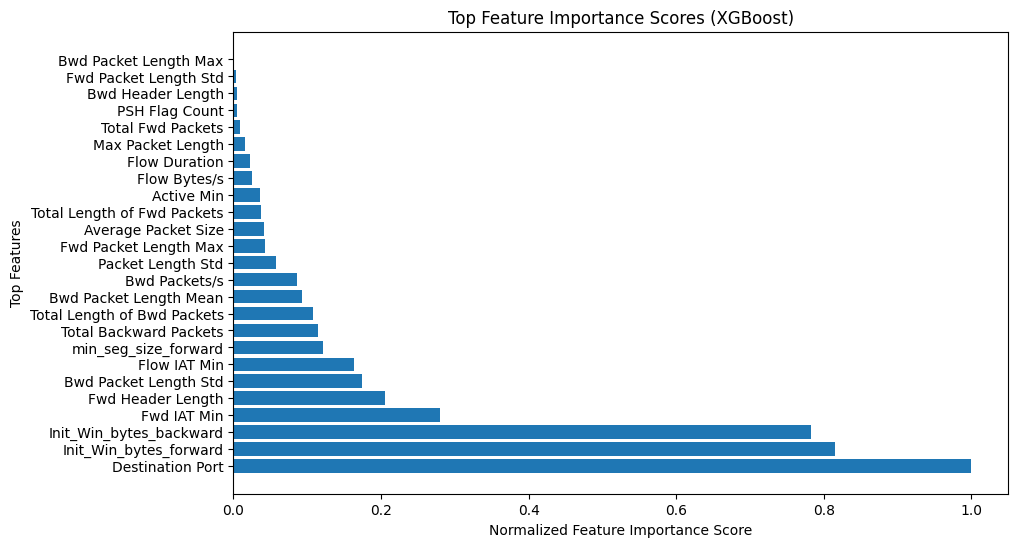

In [41]:
def extract_top_features_xgboost(model, top_n, X_train, normalize=True, printing=True, plotting=True):
    """
    Extracts and visualizes the top N feature importance scores from an XGBoost model.
    Optionally normalizes the importance scores.

    Parameters:
        model (xgb.Booster): Trained XGBoost model.
        top_n (int): Number of top features to extract.
        X_train (pd.DataFrame): Training data used to train the model.
        normalize (bool): Whether to normalize the feature importance scores.
        printing (bool): Whether to print the top feature names.
        plotting (bool): Whether to plot the feature importance scores.

    Returns:
        dict: Dictionary of feature importance scores for the top N features.
    """
    # Extract feature importances from XGBoost model
    feature_importance_scores = model.get_score(importance_type='weight')  # 'weight', 'gain', 'cover', etc.
    
    # Convert feature importance scores to a sorted list
    sorted_feature_importances = sorted(feature_importance_scores.items(), key=lambda x: x[1], reverse=True)
    
    # Select top N features
    top_n_features = sorted_feature_importances[:top_n]
    top_feature_names = [x[0] for x in top_n_features]
    top_feature_scores = [x[1] for x in top_n_features]
    
    # Normalize feature importance scores (optional)
    if normalize:
        # Min-Max Normalization
        min_score = min(top_feature_scores)
        max_score = max(top_feature_scores)
        top_feature_scores = [(x - min_score) / (max_score - min_score) for x in top_feature_scores]
        # Alternatively, use Sum Normalization:
        # total_score = sum(top_feature_scores)
        # top_feature_scores = [x / total_score for x in top_feature_scores]
    
    if printing:
        print("Top", top_n, "Features:")
        for name, score in zip(top_feature_names, top_feature_scores):
            print(f"{name}: {score:.4f}")
        print('\n')

    # Visualizing top features with a bar plot
    if plotting:
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(top_feature_names)), top_feature_scores)
        plt.yticks(range(len(top_feature_names)), top_feature_names, rotation=0)
        plt.xlabel("Normalized Feature Importance Score" if normalize else "Feature Importance Score")
        plt.ylabel("Top Features")
        plt.title("Top Feature Importance Scores (XGBoost)")
        plt.show()
    
    return dict(zip(top_feature_names, top_feature_scores))

# Example usage with XGBoost model
# Assuming `xgb_clf` is your trained XGBoost model
top_scores_xgb = extract_top_features_xgboost(model=xgb_clf, top_n=25, X_train=X_train, 
                                              normalize=True, printing=True, plotting=True)

In [40]:
def extract_worst_features_xgboost(model, worst_n, X_train, normalize=True, printing=True):
    """
    Extracts and displays the worst N feature importance scores from an XGBoost model.
    Optionally normalizes the importance scores.

    Parameters:
        model (xgb.Booster): Trained XGBoost model.
        worst_n (int): Number of worst features to extract.
        X_train (pd.DataFrame): Training data used to train the model.
        normalize (bool): Whether to normalize the feature importance scores.
        printing (bool): Whether to print the worst feature names.

    Returns:
        dict: Dictionary of feature importance scores for the worst N features.
    """
    # Extract feature importances from XGBoost model
    feature_importance_scores = model.get_score(importance_type='weight')  # 'weight', 'gain', 'cover', etc.
    
    # Convert feature importance scores to a sorted list (ascending order for worst features)
    sorted_feature_importances = sorted(feature_importance_scores.items(), key=lambda x: x[1])
    
    # Select worst N features
    worst_n_features = sorted_feature_importances[:worst_n]
    worst_feature_names = [x[0] for x in worst_n_features]
    worst_feature_scores = [x[1] for x in worst_n_features]
    
    # Normalize feature importance scores (optional)
    if normalize:
        # Min-Max Normalization
        min_score = min(worst_feature_scores)
        max_score = max(worst_feature_scores)
        worst_feature_scores = [(x - min_score) / (max_score - min_score) for x in worst_feature_scores]
        # Alternatively, use Sum Normalization:
        # total_score = sum(worst_feature_scores)
        # worst_feature_scores = [x / total_score for x in worst_feature_scores]
    
    if printing:
        print(f"Worst {worst_n} Features:")
        print(", ".join([f"{name}: {score:.4f}" for name, score in zip(worst_feature_names, worst_feature_scores)]))
        print('\n')
    
    return dict(zip(worst_feature_names, worst_feature_scores))

# Example usage with XGBoost model
worst_scores_xgb = extract_worst_features_xgboost(model=xgb_clf, worst_n=25, X_train=X_train, 
                                                  normalize=True, printing=True)

Worst 25 Features:
SYN Flag Count: 0.0000, Fwd Packet Length Min: 0.1038, Idle Std: 0.1585, Subflow Fwd Packets: 0.1967, Avg Fwd Segment Size: 0.2678, Subflow Fwd Bytes: 0.4481, Idle Mean: 0.4699, Avg Bwd Segment Size: 0.4918, Idle Max: 0.5082, Fwd Packets/s: 0.5355, Bwd IAT Max: 0.5738, Subflow Bwd Bytes: 0.5847, Packet Length Variance: 0.5956, Fwd PSH Flags: 0.6230, Subflow Bwd Packets: 0.6284, Down/Up Ratio: 0.7158, Min Packet Length: 0.7650, ACK Flag Count: 0.8361, Active Mean: 0.8634, Active Max: 0.8634, Flow IAT Max: 0.8743, URG Flag Count: 0.8852, Bwd IAT Std: 0.9126, Bwd IAT Total: 1.0000, Fwd Header Length.1: 1.0000




In [42]:
def select_features_xgboost(model, threshold, X_train, normalize=True, printing=True):
    """
    Selects features with importance scores below a specified threshold from an XGBoost model.
    Optionally normalizes the importance scores.

    Parameters:
        model (xgb.Booster): Trained XGBoost model.
        threshold (float): Importance score threshold below which features are considered insignificant.
        X_train (pd.DataFrame): Training data used to train the model.
        normalize (bool): Whether to normalize the feature importance scores.
        printing (bool): Whether to print the insignificant feature names.

    Returns:
        list: Names of features with importance scores below the threshold.
    """
    # Extract feature importances from XGBoost model
    feature_importance_scores = model.get_score(importance_type='weight')  # 'weight', 'gain', 'cover', etc.
    
    # Convert feature importance scores to a dictionary with feature names as keys
    feature_importance_dict = {feature: score for feature, score in feature_importance_scores.items()}
    
    # Normalize feature importance scores (optional)
    if normalize:
        # Min-Max Normalization
        min_score = min(feature_importance_dict.values())
        max_score = max(feature_importance_dict.values())
        feature_importance_dict = {feature: (score - min_score) / (max_score - min_score) 
                                   for feature, score in feature_importance_dict.items()}
        # Alternatively, use Sum Normalization:
        # total_score = sum(feature_importance_dict.values())
        # feature_importance_dict = {feature: score / total_score 
        #                            for feature, score in feature_importance_dict.items()}
    
    # Find features with importance scores below the threshold
    insignificant_features = [feature for feature, score in feature_importance_dict.items() 
                              if score <= threshold]
    
    if printing:
        print(f"{len(insignificant_features)} Features with Insignificant Importance (≤ {threshold}): \n")
        print(", ".join(insignificant_features))
    
    return insignificant_features

# Example usage with XGBoost model
insignificant_features = select_features_xgboost(model=xgb_clf, threshold=0.1, 
                                                 X_train=X_train, normalize=True, printing=True)
print(f"Number of features that will be eliminated: {len(insignificant_features)}")

38 Features with Insignificant Importance (≤ 0.1): 

Fwd Packet Length Min, Bwd Packet Length Min, Flow Packets/s, Flow IAT Mean, Flow IAT Max, Fwd IAT Total, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Bwd IAT Total, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Fwd PSH Flags, Fwd Packets/s, Min Packet Length, Packet Length Mean, Packet Length Variance, FIN Flag Count, SYN Flag Count, ACK Flag Count, URG Flag Count, Down/Up Ratio, Avg Fwd Segment Size, Avg Bwd Segment Size, Fwd Header Length.1, Subflow Fwd Packets, Subflow Fwd Bytes, Subflow Bwd Packets, Subflow Bwd Bytes, act_data_pkt_fwd, Active Mean, Active Std, Active Max, Idle Mean, Idle Std, Idle Max, Idle Min
Number of features that will be eliminated: 38


In [43]:
def feature_elimination_xgboost(model, threshold, X_train, X_val, X_test, normalize=True, printing=True):
    """
    Eliminates features with importance scores below a specified threshold from the dataset.
    Drops these features from the training, validation, and test sets.

    Parameters:
        model (xgb.Booster): Trained XGBoost model.
        threshold (float): Importance score threshold below which features are considered insignificant.
        X_train (pd.DataFrame): Training data.
        X_val (pd.DataFrame): Validation data.
        X_test (pd.DataFrame): Test data.
        normalize (bool): Whether to normalize the feature importance scores.
        printing (bool): Whether to print the number of remaining features.

    Returns:
        list: A list containing the updated training, validation, and test sets with insignificant features removed.
    """
    # Extract insignificant features
    insignificant_features = select_features_xgboost(model=model, threshold=threshold, 
                                                     X_train=X_train, normalize=normalize, printing=False)
    
    # Drop columns with insignificant importance from all sets
    df_list = [X_train, X_val, X_test]
    df_list = [df.copy() for df in df_list]  # Create copies to avoid modifying the original data
    df_list = [df.drop(columns=insignificant_features) for df in df_list]
    
    if printing:
        print(f"Number of features that will be kept: {len(df_list[0].columns)}\n")
        print("List of remaining features:", df_list[0].columns.tolist())
    
    return df_list

# Example usage with XGBoost model
elimination_params_0 = dict(model=xgb_clf, threshold=0.1, 
                            X_train=X_train, X_val=X_val, X_test=X_test, 
                            normalize=True, printing=True)
[X_1_train, X_1_val, X_1_test] = feature_elimination_xgboost(**elimination_params_0)

Number of features that will be kept: 40

List of remaining features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Min', 'Bwd IAT Min', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Max Packet Length', 'Packet Length Std', 'RST Flag Count', 'PSH Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'Active Min']


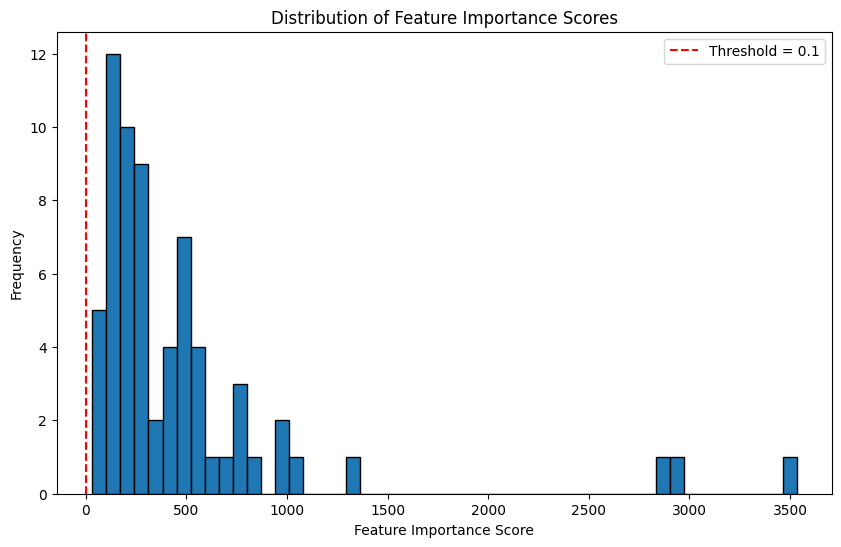

In [44]:
# Extract feature importance scores
feature_importance_scores = xgb_clf.get_score(importance_type='weight')
scores = list(feature_importance_scores.values())

# Plot histogram of feature importance scores
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=50, edgecolor='black')
plt.xlabel("Feature Importance Score")
plt.ylabel("Frequency")
plt.title("Distribution of Feature Importance Scores")
plt.axvline(x=0.1, color='red', linestyle='--', label="Threshold = 0.1")
plt.legend()
plt.show()

In [45]:
print("Classification Report:\n", classification_report(Y_test, Y_pred))

print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

NameError: name 'Y_pred' is not defined